In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
import os
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve
from scipy.spatial import ConvexHull
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Baskerville']

In [5]:
data_directory = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2_1/week2/Similar_FOV_ts_darkfix_npz/test"
output_dir = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2_1/week2/Similar_FOV_ts_airPLS_rubberband_npz/test"
os.makedirs(output_dir, exist_ok= True)

In [6]:

n_npy = sum(
    1 for f in os.listdir(data_directory)
    if f.lower().endswith(".npz") and os.path.isfile(os.path.join(data_directory, f))
)

print("Number of .npz files:", n_npy)

Number of .npz files: 1


In [7]:
def WhittakerSmooth(x,w,lambda_,differences=1):
    '''
    Penalized least squares algorithm for background fitting
    
    input
        x: input data (i.e. chromatogram of spectrum)
        w: binary masks (value of the mask is zero if a point belongs to peaks and one otherwise)
        lambda_: parameter that can be adjusted by user. The larger lambda is,  the smoother the resulting background
        differences: integer indicating the order of the difference of penalties
    
    output
        the fitted background vector
    '''
    X=np.matrix(x)
    m=X.size
    E=eye(m,format='csc')
    for i in range(differences):
        E=E[1:]-E[:-1] # numpy.diff() does not work with sparse matrix. This is a workaround.
    W=diags(w,0,shape=(m,m))
    A=csc_matrix(W+(lambda_*E.T*E))
    B=csc_matrix(W*X.T)
    background=spsolve(A,B)
    return np.array(background)

def airPLS(x, lambda_=2000, porder=1, itermax=15):
    '''
    Adaptive iteratively reweighted penalized least squares for baseline fitting
    
    input
        x: input data (i.e. chromatogram of spectrum)
        lambda_: parameter that can be adjusted by user. The larger lambda is,  the smoother the resulting background, z
        porder: adaptive iteratively reweighted penalized least squares for baseline fitting
    
    output
        the fitted background vector
    '''
    m=x.shape[0]
    w=np.ones(m)
    for i in range(1,itermax+1):
        z=WhittakerSmooth(x,w,lambda_, porder)
        d=x-z
        dssn=np.abs(d[d<0].sum())
        if(dssn<0.001*(abs(x)).sum() or i==itermax):
            #if(i==itermax): print('WARNING max iteration reached!')
            break
        w[d>=0]=0 # d>0 means that this point is part of a peak, so its weight is set to 0 in order to ignore it
        w[d<0]=np.exp(i*np.abs(d[d<0])/dssn)
        w[0]=np.exp(i*(d[d<0]).max()/dssn) 
        w[-1]=w[0]
    return z


# Baseline correction
def rubberband(x, y):
    # Find the convex hull
    v = ConvexHull(np.array(list(zip(x, y)))).vertices

    # Rotate convex hull vertices until they start from the lowest one
    v = np.roll(v, -v.argmin())
    # Leave only the ascending part
    v = v[:v.argmax()]

    # Create baseline using linear interpolation between vertices #return the baseline
    return np.interp(x, x[v], y[v])

# Function to shift each time series in the array with respect to its minimum value
def move_up_ts(ts_array):
    # Subtract the minimum value of each time series
    shifted_ts_array = ts_array - np.min(ts_array, axis=1, keepdims=True)
    return shifted_ts_array

Number of .npz files: 1

Test2_Week_2_2022_09_01_12_12_05_Fluo17012_CS1A1S1_ts_labels_darkfix.npz  Ts shape=(203, 840)
  global min over all neurons (after crop) = 9.81731
  global min AFTER airPLS+rubberband = 0
  global min AFTER shift airPLS+rubberband = 0


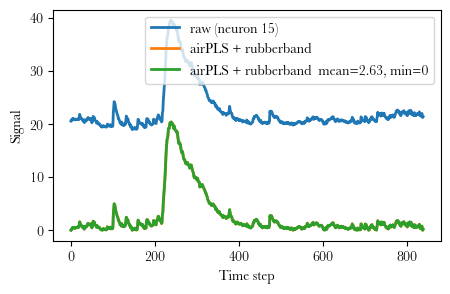


 after processing,  Ts shape=(203, 840)
Saved: /Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2_1/week2/Similar_FOV_ts_airPLS_rubberband_npz/test/Test2_Week_2_2022_09_01_12_12_05_Fluo17012_CS1A1S1_ts_labels_darkfix_airPLS_RubberBand.npz

Done. Files saved in: /Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2_1/week2/Similar_FOV_ts_airPLS_rubberband_npz/test


In [8]:
# assumes you already have: airPLS(y), rubberband(x,y), move_up_ts(TS)

def baseline_correction_npz(
    data_directory,
    output_dir,
    do_plots=True,
    ex_idx1=15,
    crop_T=840,                 # keep your exact behavior
    suffix="_airPLS_RubberBand"
):
    os.makedirs(output_dir, exist_ok=True)
    npz_files = sorted([f for f in os.listdir(data_directory) if f.lower().endswith(".npz")])
    print("Number of .npz files:", len(npz_files))

    for fname in npz_files:
        path = os.path.join(data_directory, fname)
        base = os.path.splitext(fname)[0]

        z = np.load(path, allow_pickle=True)
        if "ts" not in z.files:
            print(f"Skipping {fname} (no 'ts' key). keys={z.files}")
            z.close()
            continue

        ts_full = z["ts"]               # (N, Tfull)
        Ts = ts_full[:, :crop_T]        # EXACT like your code
        Ts = Ts.astype(np.float32, copy=True)

        print(f"\n{fname}  Ts shape={Ts.shape}")

        # check overall min of each trace (per neuron) + global min
        per_trace_min = np.nanmin(Ts, axis=1)      # shape (N,)
        global_min = float(np.nanmin(per_trace_min))
        print(f"  global min over all neurons (after crop) = {global_min:.6g}")

        N, T = Ts.shape
        x = np.arange(T, dtype=np.float32)

        # -------------------------
        # 1) Mean subtraction (per trace)
        # -------------------------
        TS_avg = Ts - Ts.mean(axis=1, keepdims=True)

        # -------------------------
        # 2) airPLS baseline correction (per trace): y - airPLS(y)
        # -------------------------
        TS_air = np.empty_like(TS_avg, dtype=np.float32)
        for i in range(N):
            y = TS_avg[i].astype(np.float64, copy=False)
            TS_air[i] = (y - airPLS(y)).astype(np.float32)

        # -------------------------
        # 3) Rubberband correction (per trace)
        # -------------------------
        TS_avg_rub = np.empty_like(TS_avg, dtype=np.float32)
        TS_air_rub = np.empty_like(TS_air, dtype=np.float32)

        for i in range(N):
            TS_avg_rub[i] = TS_avg[i] - rubberband(x, TS_avg[i])
            TS_air_rub[i] = TS_air[i] - rubberband(x, TS_air[i])

        # -------------------------
        # 4) Optional shifting (kept exactly like your code)
        # -------------------------
        shifted_air     = move_up_ts(TS_air)
        shifted_air_rub = move_up_ts(TS_air_rub)

        # (optional) check min after correction too
        global_min_after = float(np.nanmin(TS_air_rub))
        print(f"  global min AFTER airPLS+rubberband = {global_min_after:.6g}")
        
        
        global_min_after_shift = float(np.nanmin(shifted_air_rub))
        print(f"  global min AFTER shift airPLS+rubberband = {global_min_after_shift:.6g}")

        # -------------------------
        # Plots
        # -------------------------
        if do_plots:
            i1 = min(ex_idx1, N - 1)

            plt.figure(figsize=(5, 3))

            y = Ts[i1]
            plt.plot(y, label=f"raw (neuron {i1})", linewidth=2)

            y = TS_air_rub[i1]
            plt.plot(y, label="airPLS + rubberband", linewidth=2)
            
            y = shifted_air_rub[i1]
            plt.plot(y, label=f"airPLS + rubberband  mean={y.mean():.3g}, min={y.min():.3g}", linewidth=2)

            plt.xlabel("Time step")
            plt.ylabel("Signal")
            plt.legend()
            plt.show()

        # -------------------------
        # Save (per file) — keep SAME ids/metadata, replace ts only
        # -------------------------
        print(f"\n after processing,  Ts shape={shifted_air_rub.shape}")
        out_dict = {k: z[k] for k in z.files}     # preserve all keys
        out_dict["ts"] = shifted_air_rub.astype(np.float32)

        z.close()

        out_path = os.path.join(output_dir, base + suffix + ".npz")
        np.savez(out_path, **out_dict)
        print("Saved:", out_path)
        

    print("\nDone. Files saved in:", output_dir)

# Run:
baseline_correction_npz(data_directory, output_dir, do_plots=True)

In [16]:

#npy
def baseline_correction(data_directory, output_dir, do_plots=True, ex_idx1=15, ex_idx2=185):
    os.makedirs(output_dir, exist_ok=True)
    npy_files = sorted([f for f in os.listdir(data_directory) if f.lower().endswith(".npy")])
    print("Number of .npy files:", len(npy_files))

    for fname in npy_files:
        path = os.path.join(data_directory, fname)
        base = os.path.splitext(fname)[0]

        ts = np.load(path)  # (N, T)
        Ts = ts[:, :840]  
        print(f"\n{fname}  Ts shape={Ts.shape}")

        N, T = Ts.shape
        x = np.arange(T)

        # -------------------------
        # 1) Mean subtraction (per trace)
        # -------------------------
        TS_avg = Ts - Ts.mean(axis=1, keepdims=True)

        # -------------------------
        # 2) airPLS baseline correction (per trace)
        # NOTE: you used c1 = y1 - airPLS(y1)
        # -------------------------
        TS_air = np.empty_like(TS_avg, dtype=np.float32)
        for i in range(N):
            y = TS_avg[i].astype(np.float64, copy=False)
            TS_air[i] = (y - airPLS(y)).astype(np.float32)

        # -------------------------
        # 3) Rubberband correction (per trace)
        # -------------------------
        TS_avg_rub = np.empty_like(TS_avg, dtype=np.float32)
        TS_air_rub = np.empty_like(TS_air, dtype=np.float32)

        for i in range(N):
            TS_avg_rub[i] = TS_avg[i] - rubberband(x, TS_avg[i])
            TS_air_rub[i] = TS_air[i] - rubberband(x, TS_air[i])

        # -------------------------
        # 4) Optional shifting (if your function exists)
        # -------------------------
        shifted_air     = move_up_ts(TS_air)       # optional
        shifted_air_rub = move_up_ts(TS_air_rub)   # optional
        


        # -------------------------
        # Plots
        # -------------------------
        if do_plots:
            i1 = min(ex_idx1, N - 1)

            plt.figure(figsize=(7,5))

            y = Ts[i1]
            plt.plot(y, label=f"raw (neuron {i1})", linewidth=2)

#             y = TS_avg[i1]
#             plt.plot(y, label=f"mean-subtracted  mean={y.mean():.3g}, min={y.min():.3g}", linewidth=2)

            y = TS_air[i1]
            plt.plot(y, label=f"airPLS (after mean-sub)", linewidth=2)

            y = TS_air_rub[i1]
            plt.plot(y, label=f"airPLS + rubberband  mean={y.mean():.3g}, min={y.min():.3g}", linewidth=2)

            plt.xlabel("Time step")
            plt.ylabel("Signal")
            plt.legend()
            plt.show()
        # -------------------------
        # Save (per file)
        # -------------------------
        out_path = os.path.join(output_dir, base + "_all_SFOV_airPLS_RubberBand.npy")
        np.save(out_path, TS_air_rub)
        print("Saved:", out_path)

    print("\nDone. Files saved in:", output_dir)

# Run
baseline_correction(data_directory, output_dir, do_plots=True)

Number of .npy files: 0

Done. Files saved in: /Volumes/DATA/DHM 1082/yaza3022/hIPSC/Control_iPSCs/Fluo/Test2_1/week6/Similar_FOV_ts_airPLS_rubberband_npz
